/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unle

Training Forward Model...


/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=10` in the `DataLoader` to improve performance.


Epoch 29: 100%|██████████| 157/157 [00:02<00:00, 62.90it/s, v_num=1693, train_loss_step=0.618, train_loss_epoch=0.617]

`Trainer.fit` stopped: `max_epochs=30` reached.


...

Plotting forward attention heatmap...
Training Backward Model...



  | Name       | Type               | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | we         | Embedding          | 60     | train | 0    
1 | pe         | PositionalEncoding | 0      | train | 0    
2 | attn       | AttentionModel     | 1.3 K  | train | 0    
3 | output_prj | Linear             | 63     | train | 0    
4 | loss       | CrossEntropyLoss   | 0      | train | 0    
------------------------------------------------------------------
1.4 K     Trainable params
0         Non-trainable params
1.4 K     Total params
0.006     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 29: 100%|██████████| 157/157 [00:02<00:00, 62.23it/s, v_num=1694, train_loss_step=0.616, train_loss_epoch=0.617]

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 157/157 [00:02<00:00, 61.96it/s, v_num=1694, train_loss_step=0.616, train_loss_epoch=0.617]
Plotting backward attention heatmap...
Analyzing Models...
FW/BW LOSS COMPARISON
Performing PCA on Forward and Backward Latents...
FW/BW LATENTS COMPARISON
STATISTICAL COMPLEXITY COMPARISON

[1/2] Forward Model
----------------------------------------------------------------------
  Empirical (use_t='last'):   0.9447 bits
  Theoretical:               0.9183 bits
  Error:                     0.0264 bits

[2/2] Backward Model
----------------------------------------------------------------------
  Empirical (use_t='first'):  1.3853 bits
  Theoretical:               1.5656 bits
  Error:                     0.1803 bits

SUMMARY

Empirical Complexity:
  Forward (last):   0.9447 bits
  Backward (first): 1.3853 bits
  Difference (FW - BW): -0.4405 bits

Theoretical Complexity:
  Forward:  0.9183 bits
  Backward: 1.5656 bits
  Difference (FW - BW): -0.6473 bits


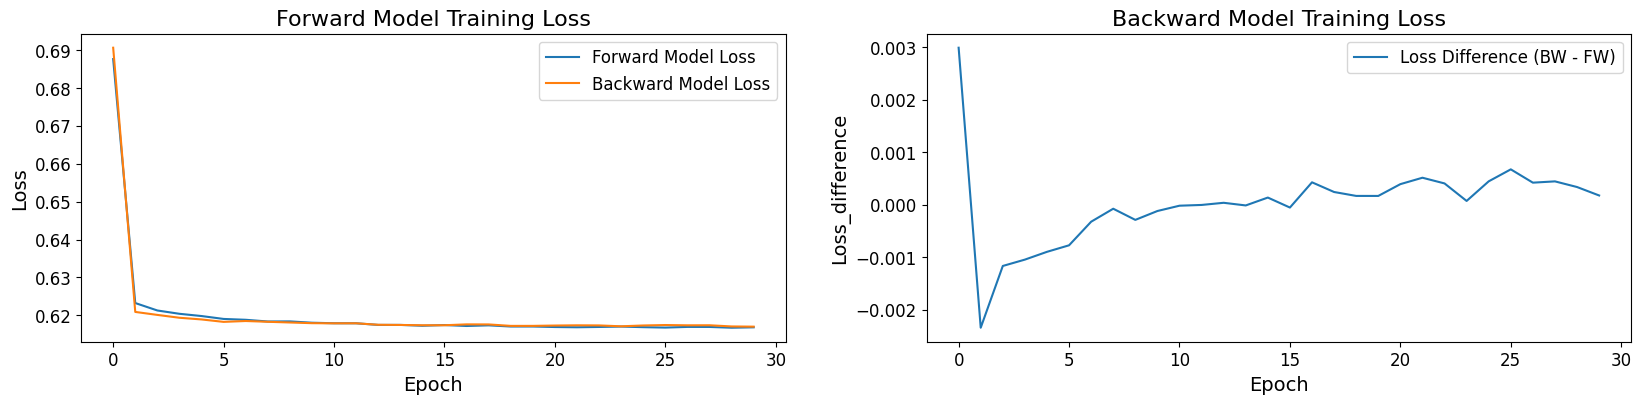

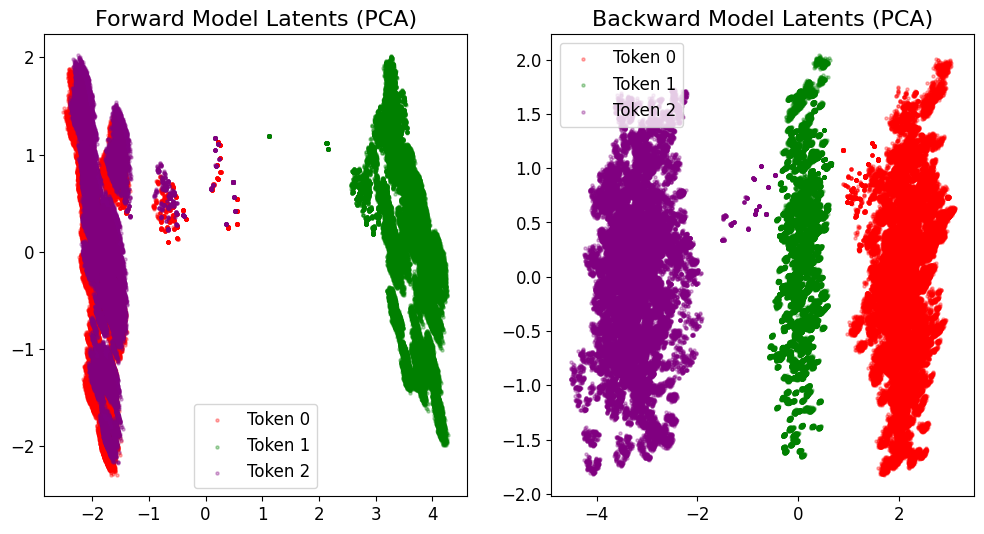

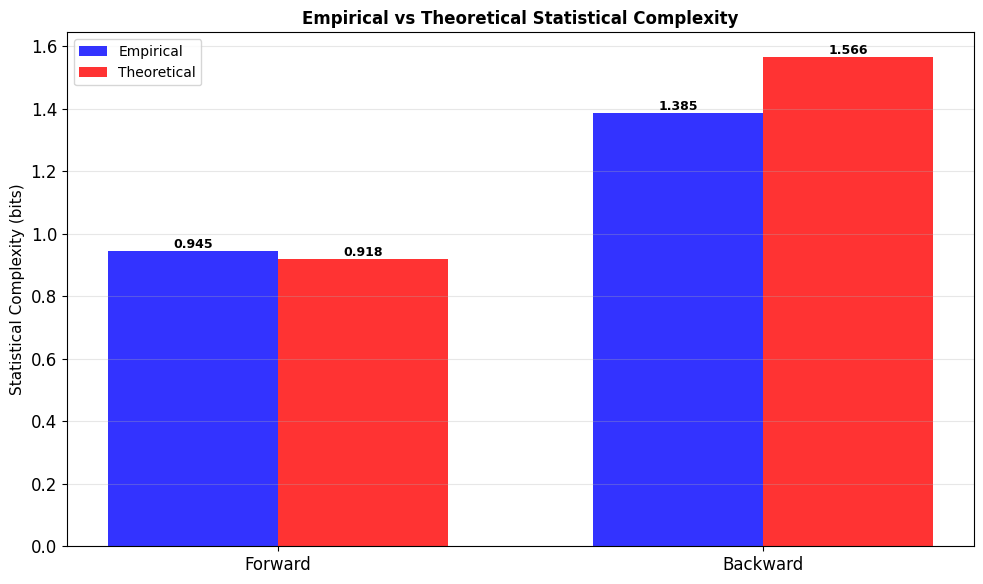

PERPLEXITY COMPARISON
Forward Model Perplexity:  1.8502
Backward Model Perplexity: 31.1454


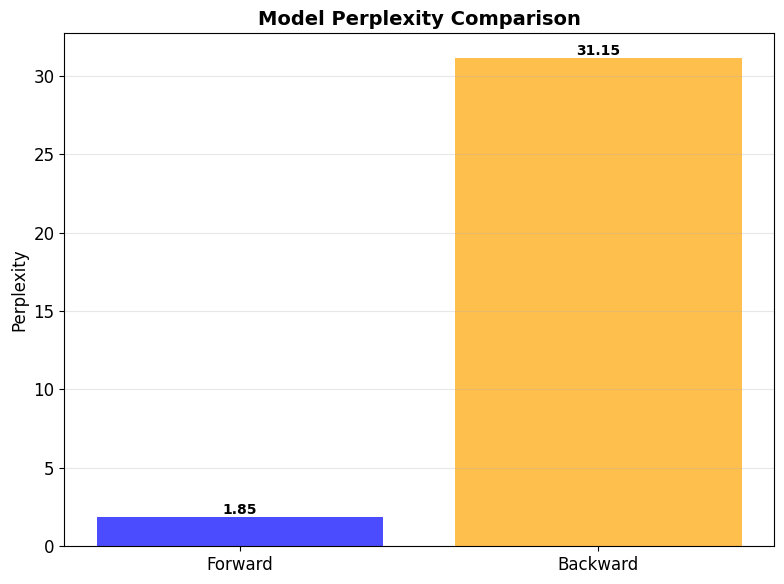


Analysis complete!


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from Training_model import train_model
from Data_generation import make_loader
from OneHot_model import OneHotDecoder
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
    statistical_complexity_compare,
    FW_BW_attention_comparison,
    FW_BW_loss_comparison,
    compare_FW_BW_latents,
    plot_attention_heatmap,
    plot_perplexity
)


    # Hyperparameters
num_token = 3
d_model = 20
max_len = 500
batch_size = 32
num_samples = 5000
max_epochs = 30
lr = 1e-2
p, q = 0.4, 0.8

    # Data Loader
train_loader = make_loader(pp=p, qq=q, batch_size=batch_size, seq_len=max_len, num_samples=num_samples)

    # Train Forward Model
print("Training Forward Model...")
recorder_fw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='forward'
)
    
    # Get sample data for visualization (FIX 17: Use actual data, not torch.arange!)
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]  # Get first sequence from batch (contains tokens in [0,1,2])
    
print("Plotting forward attention heatmap...")
    #plot_attention_heatmap(recorder_fw.model, sample_seq)

    # Train Backward Model
print("Training Backward Model...")
recorder_bw = train_model(
    train_loader, 
    num_token=num_token, 
    d_model=d_model, 
    max_len=max_len, 
    max_epochs=max_epochs, 
    lr=lr, 
    mode='backward'
)
    
print("Plotting backward attention heatmap...")
    #plot_attention_heatmap(recorder_bw.model, sample_seq)

    # Model Analysis
print("Analyzing Models...")

    # Loss comparison needs recorders (has .epoch_loss)
FW_BW_loss_comparison(recorder_fw, recorder_bw)

    # Get sample data
data_iter = iter(train_loader)
sample_inputs, _ = next(data_iter)
sample_seq = sample_inputs[0]

    # All these need models (have .eval(), .forward(), etc.)
    #FW_BW_attention_comparison(recorder_fw.model, recorder_bw.model, sample_seq)
compare_FW_BW_latents(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)
statistical_complexity_compare(recorder_fw.model, recorder_bw.model, data_loader=train_loader, p=p, q=q, max_batches=10)
plot_perplexity(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)  # ← Fixed!

print("\nAnalysis complete!")


In [3]:
from Model_analysis import compare_FW_BW_latents, latent_extraction

fw_model = recorder_fw.model
bw_model = recorder_bw.model
data_loader = train_loader
max_batches = 10

latents_fw, inputs_fw, _ = latent_extraction(fw_model, data_loader, max_batches)
latents_bw, inputs_bw, _ = latent_extraction(bw_model, data_loader, max_batches)



In [4]:
from Data_generation import HMM_generation
HMM_generation(num_samples = 10, seq_len = 5, p = 0.6, q = 0.4)

([[1, 2, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 1, 2],
  [0, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1],
  [0, 1, 2, 1, 1, 1, 1, 1, 2, 0, 1, 1, 2, 1, 2],
  [0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 2, 0, 1, 2, 1],
  [1, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1],
  [1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1],
  [1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2],
  [0, 1, 2, 1, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1],
  [1, 2, 0, 0, 1, 1, 1, 2, 0, 1, 1, 2, 1, 1, 2]],
 [[1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0],
  [0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1],
  [0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0],
  [0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1],
  [1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1],
  [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1],
  [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0],
  [0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1],
  [1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0]])

In [5]:
latents_fw

array([[[-0.596618  ,  0.8211591 ,  0.3207058 , ..., -0.16504705,
          0.5789852 , -0.04215795],
        [ 0.5834905 ,  1.0397291 ,  0.21691313, ...,  0.6993904 ,
         -0.19186343,  1.0329456 ],
        [ 0.9286603 ,  0.17622   ,  0.35845992, ...,  1.2348846 ,
         -0.40106547,  1.2457533 ],
        ...,
        [-0.09705763, -0.9792981 ,  0.45729524, ...,  2.0055995 ,
         -0.01493194,  2.007997  ],
        [-0.83257526, -0.36333758,  0.8094996 , ...,  1.9970648 ,
         -0.00998139,  1.992184  ],
        [-0.7114931 ,  0.5794612 ,  1.0604793 , ...,  1.9827491 ,
         -0.00393951,  1.9588042 ]],

       [[-0.5464026 ,  1.2472126 , -0.07628524, ..., -0.08068371,
          0.5134621 ,  0.0898416 ],
        [ 0.2990027 ,  0.78411376,  0.3032876 , ..., -0.06817275,
          0.5054877 ,  0.09863788],
        [ 0.3697675 , -0.17302865,  0.6273416 , ..., -0.06128854,
          0.5027607 ,  0.10242659],
        ...,
        [-0.25540257, -1.0080321 ,  0.3328852 , ...,  

In [6]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

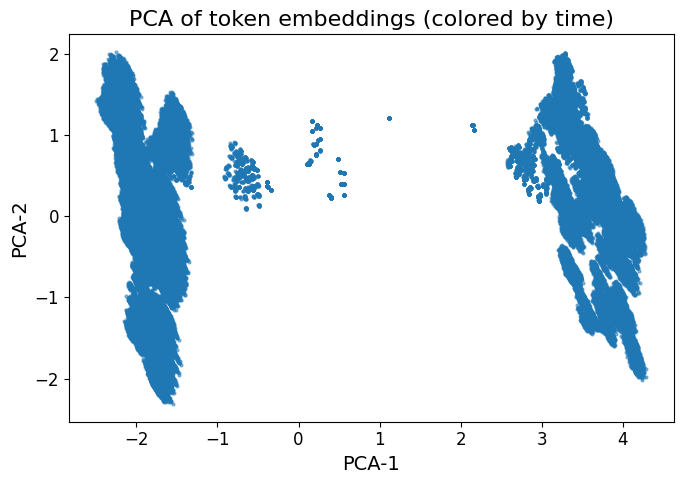

In [7]:


pca = PCA(n_components=2)
X_pca = pca.fit_transform(latents_fw.reshape(-1, latents_fw.shape[-1]))  # (320*509, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_pca[:, 0], X_pca[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("PCA of token embeddings (colored by time)")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
plt.tight_layout()



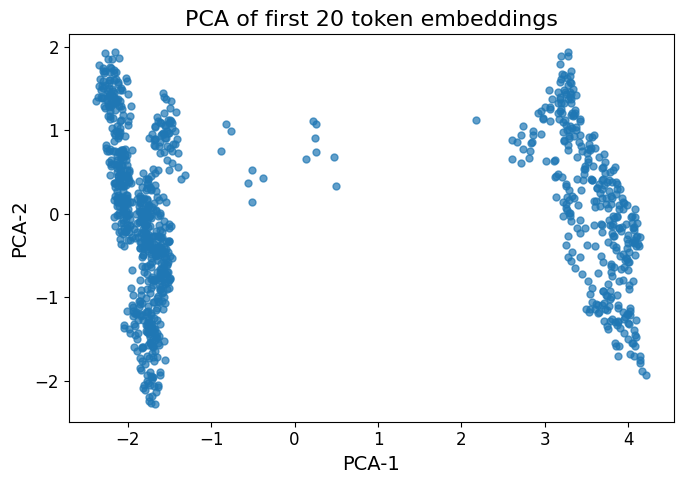

In [8]:

n = 1000

flat_latent = latents_fw.reshape(-1, latents_fw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 
red_pca = PCA(n_components=2)
X_red_pca = red_pca.fit_transform(reduced_latents)  # (20, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_red_pca[:, 0], X_red_pca[:, 1], 'o', markersize=5, alpha=0.7)
plt.title("PCA of first 20 token embeddings")
plt.xlabel("PCA-1"); plt.ylabel("PCA-2")
plt.tight_layout()
plt.show()  

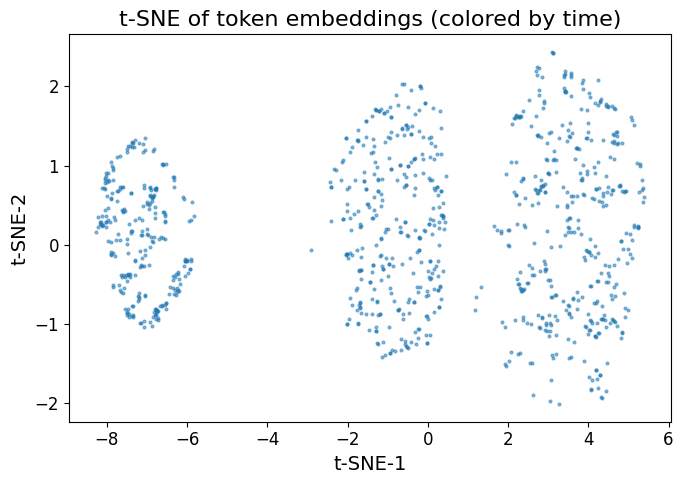

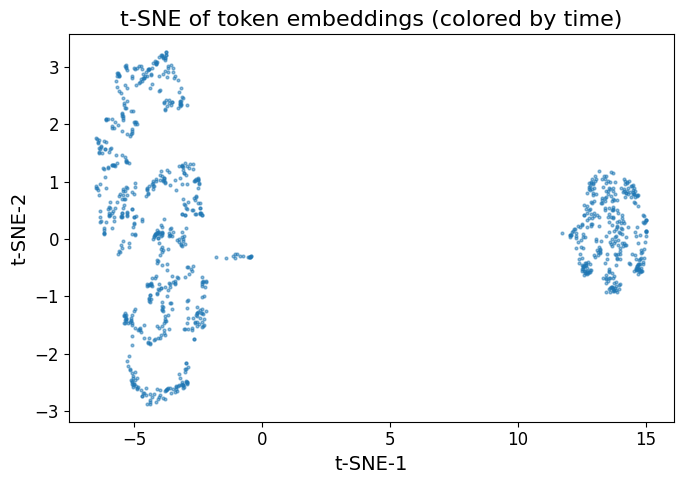

In [9]:

n = 1000

tsne = TSNE(n_components=2, random_state=42, perplexity = 300)
flat_latent = latents_bw.reshape(-1, latents_bw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 
X_tsne = tsne.fit_transform(reduced_latents.reshape(-1, reduced_latents.shape[-1]))  # (320*509, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_tsne[:, 0], X_tsne[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()

tsne2 = TSNE(n_components=2, random_state=42, perplexity=300)
flat_latent2 = latents_fw.reshape(-1, latents_fw.shape[-1])
reduced_latents2 = flat_latent2[:n, :]
X_tsne2 = tsne2.fit_transform(reduced_latents2.reshape(-1, reduced_latents2.shape[-1]))
plt.figure(figsize=(7, 5))
plt.plot(X_tsne2[:, 0], X_tsne2[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("t-SNE of token embeddings (colored by time)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


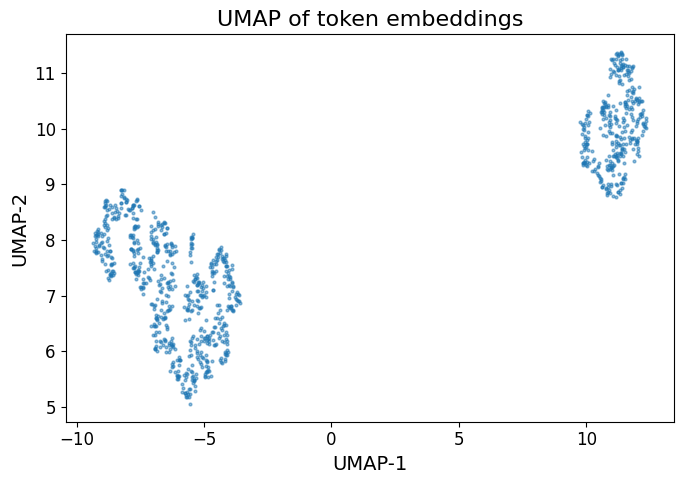

In [16]:
import umap

n = 1000
flat_latent = latents_fw.reshape(-1, latents_bw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 

reducer = umap.UMAP(n_neighbors=100, min_dist=0.1, metric="euclidean", random_state=42)
X_umap = reducer.fit_transform(reduced_latents.reshape(-1, reduced_latents.shape[-1]))  # (320*509, 2)
plt.figure(figsize=(7, 5))
plt.plot(X_umap[:, 0], X_umap[:, 1], 'o', markersize=2, alpha=0.5)
plt.title("UMAP of token embeddings")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")  
plt.tight_layout()
plt.show()

In [21]:
import umap
def draw_umap(data, color=None, n_neighbors=300, min_dist=0.1, n_components=2, metric='euclidean', title='', random_state=42):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, n_components=n_components, metric=metric, random_state=random_state)
    u = fit.fit_transform(data)

    fig = plt.figure()
    ax = fig.add_subplot(111) if n_components != 3 else fig.add_subplot(111, projection='3d')

    if color is None:
        color = np.arange(len(data))  # default: timestep coloring

    if n_components == 2:
        sc = ax.scatter(u[:,0], u[:,1], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)
    elif n_components == 3:
        sc = ax.scatter(u[:,0], u[:,1], u[:,2], c=color, s=10, cmap='plasma')
        plt.colorbar(sc)

    plt.title(title, fontsize=18)
    plt.show()


/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


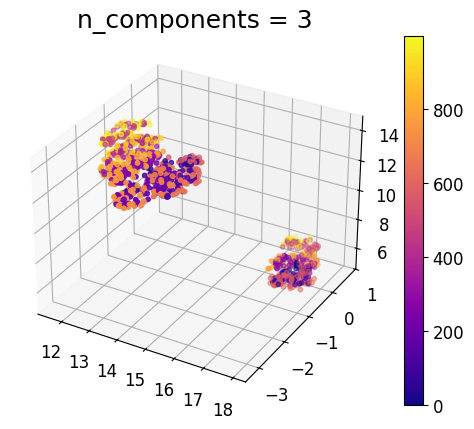

/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


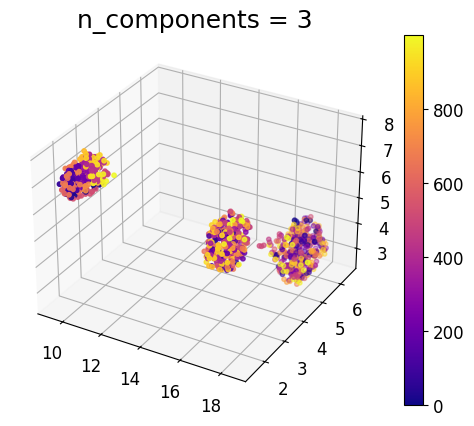

In [24]:
flat_latent = latents_fw.reshape(-1, latents_fw.shape[-1])  # (320*509, 20)
reduced_latents = flat_latent[:n, :] 
flat_latent2 = latents_bw.reshape(-1, latents_bw.shape[-1])  # (320*509, 20)
reduced_latents2 = flat_latent2[:n, :] 


draw_umap(reduced_latents, n_components=3, title='n_components = 3')
draw_umap(reduced_latents2, n_components=3, title='n_components = 3')

/Users/tisornnaphattalung/Desktop/Quantum/URECA/URECA_qt_llm/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


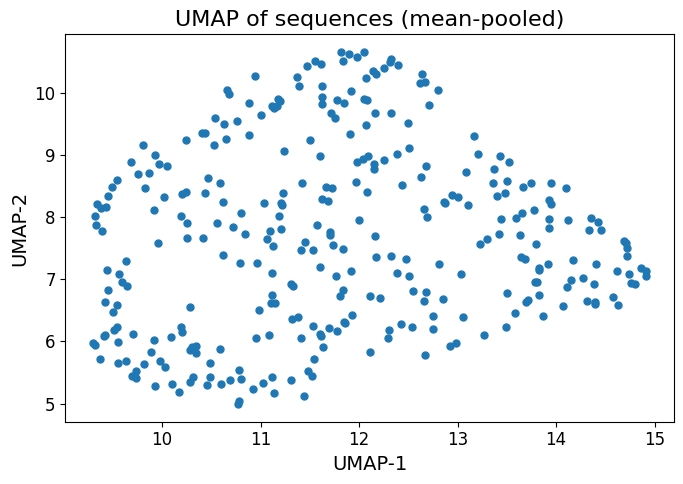

In [14]:
import numpy as np
import matplotlib.pyplot as plt

X = latents_fw  # (320, 509, 20)

# Pool tokens into one vector per sequence:
# mean pooling (common baseline)
X_seq = X.mean(axis=1)   # (320, 20)

import umap
reducer = umap.UMAP(n_neighbors=100, min_dist=0.1, metric="euclidean", random_state=0)
Y = reducer.fit_transform(X_seq)  # (320, 2)

plt.figure(figsize=(7, 5))
plt.scatter(Y[:, 0], Y[:, 1], s=25)
plt.title("UMAP of sequences (mean-pooled)")
plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2")
plt.tight_layout()
plt.show()


Performing PCA on Forward and Backward Latents...
FW/BW LATENTS COMPARISON


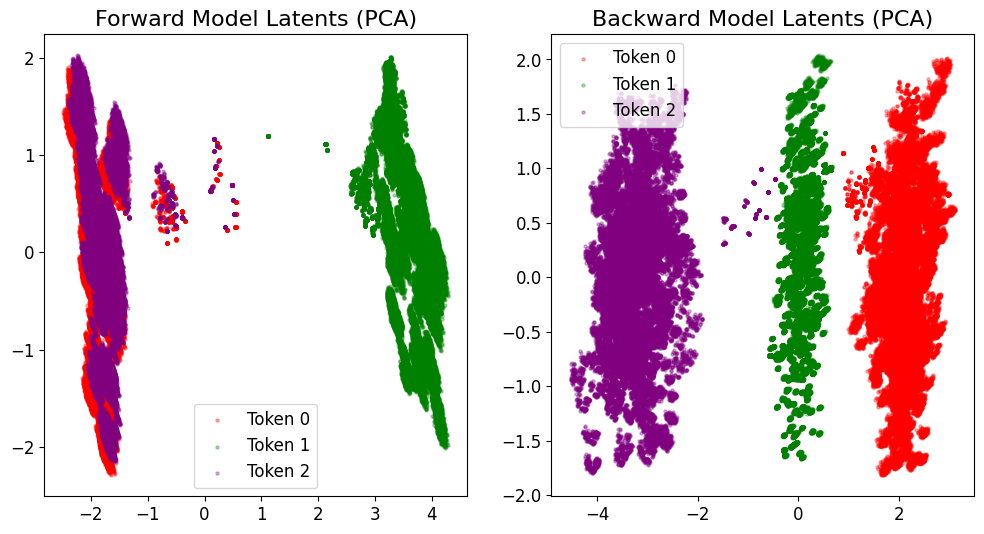

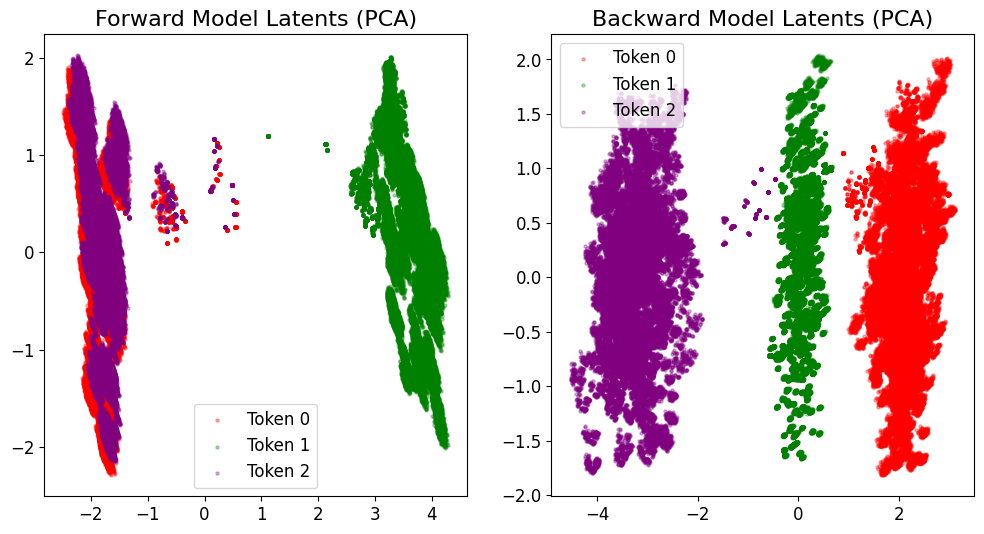

In [15]:
compare_FW_BW_latents(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from Training_model import train_model
from Data_generation import make_loader
from OneHot_model import OneHotDecoder
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
    statistical_complexity_compare,
    FW_BW_attention_comparison,
    FW_BW_loss_comparison,
    compare_FW_BW_latents,
    plot_attention_heatmap,
    plot_perplexity
)

def main():
    # Hyperparameters
    num_token = 3
    d_model = 20
    max_len = 1000
    batch_size = 32
    num_samples = 5000
    max_epochs = 50
    lr = 1e-2
    p, q = 0.3, 0.4

    # Data Loader
    train_loader = make_loader(pp=p, qq=q, batch_size=batch_size, seq_len=max_len, num_samples=num_samples)

    # Train Forward Model
    print("Training Forward Model...")
    recorder_fw = train_model(
        train_loader, 
        num_token=num_token, 
        d_model=d_model, 
        max_len=max_len, 
        max_epochs=max_epochs, 
        lr=lr, 
        mode='forward'
    )
    
    # Get sample data for visualization (FIX 17: Use actual data, not torch.arange!)
    data_iter = iter(train_loader)
    sample_inputs, _ = next(data_iter)
    sample_seq = sample_inputs[0]  # Get first sequence from batch (contains tokens in [0,1,2])
    
    print("Plotting forward attention heatmap...")
    #plot_attention_heatmap(recorder_fw.model, sample_seq)

    # Train Backward Model
    print("Training Backward Model...")
    recorder_bw = train_model(
        train_loader, 
        num_token=num_token, 
        d_model=d_model, 
        max_len=max_len, 
        max_epochs=max_epochs, 
        lr=lr, 
        mode='backward'
    )
    
    print("Plotting backward attention heatmap...")
    #plot_attention_heatmap(recorder_bw.model, sample_seq)

    # Model Analysis
    print("Analyzing Models...")

    # Loss comparison needs recorders (has .epoch_loss)
    FW_BW_loss_comparison(recorder_fw, recorder_bw)

    # Get sample data
    data_iter = iter(train_loader)
    sample_inputs, _ = next(data_iter)
    sample_seq = sample_inputs[0]

    # All these need models (have .eval(), .forward(), etc.)
    #FW_BW_attention_comparison(recorder_fw.model, recorder_bw.model, sample_seq)
    compare_FW_BW_latents(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)
    statistical_complexity_compare(recorder_fw.model, recorder_bw.model, data_loader=train_loader, p=p, q=q, max_batches=10)
    plot_perplexity(recorder_fw.model, recorder_bw.model, data_loader=train_loader, max_batches=10)  # ← Fixed!

    print("\nAnalysis complete!")


if __name__ == "__main__":
    main()

In [ ]:
from Data_generation import HMM_generation
from Data_generation import make_loader
from Training_model import train_model
from Model_analysis import (
    statistical_complexity,
    statistical_complexity_empirical,
)
import numpy as np
import matplotlib.pyplot as plt


def heatmap_theory(
    p_values=None,
    q_values=None,
):
    """
    Compute theoretical statistical complexity on a p-q grid.
    Returns:
        Ss_theory_FW: (len(p), len(q))
        Ss_theory_BW: (len(p), len(q))
        p_values, q_values (so plotting is consistent)
    """
    if p_values is None:
        p_values = np.linspace(0.01, 0.99, 100)  # avoid exact 1.0 edge cases
    if q_values is None:
        q_values = np.linspace(0.01, 0.99, 100)

    p_values = np.array(p_values, dtype=float)
    q_values = np.array(q_values, dtype=float)

    Ss_theory_FW = np.zeros((len(p_values), len(q_values)), dtype=float)
    Ss_theory_BW = np.zeros((len(p_values), len(q_values)), dtype=float)

    print(f"Computing theoretical complexity for {len(p_values)} x {len(q_values)} grid...")

    for i, p in enumerate(p_values):
        if i % 10 == 0:
            print(f"  Progress: {i}/{len(p_values)}")
        for j, q in enumerate(q_values):
            Ss_theory_FW[i, j] = statistical_complexity(p, q, mode="forward")
            Ss_theory_BW[i, j] = statistical_complexity(p, q, mode="backward")

    print("✓ Theoretical complexity computation complete")
    return Ss_theory_FW, Ss_theory_BW, p_values, q_values


def pq_experiment(
    num_token=3,
    d_model=20,
    max_len=100,
    batch_size=32,
    num_samples=2000,
    max_epochs=20,
    lr=1e-2,
    p_values=None,
    q_values=None,
    max_batches_for_empirical=10,
):
    """
    Runs empirical experiments on a p-q grid.
    Returns:
        Ss_emp: shape (2, len(p), len(q)) where Ss_emp[0]=FW, Ss_emp[1]=BW
        p_values, q_values (so plotting is consistent)
    """
    if p_values is None:
        p_values = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]
    if q_values is None:
        q_values = [0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]

    p_values = np.array(p_values, dtype=float)
    q_values = np.array(q_values, dtype=float)

    Ss_emp_FW = np.zeros((len(p_values), len(q_values)), dtype=float)
    Ss_emp_BW = np.zeros((len(p_values), len(q_values)), dtype=float)

    total = len(p_values) * len(q_values)

    for i, p in enumerate(p_values):
        for j, q in enumerate(q_values):
            idx = i * len(q_values) + j + 1
            print(f"\n{'='*70}")
            print(f"Experiment {idx}/{total}: p={p}, q={q}")
            print(f"{'='*70}")

            train_loader = make_loader(
                pp=float(p),
                qq=float(q),
                batch_size=batch_size,
                seq_len=max_len,
                num_samples=num_samples,
            )

            print("\n[1/2] Training Forward Model...")
            recorder_fw = train_model(
                train_loader,
                num_token=num_token,
                d_model=d_model,
                max_len=max_len,
                max_epochs=max_epochs,
                lr=lr,
                mode="forward",
            )

            print("\n[2/2] Training Backward Model...")
            recorder_bw = train_model(
                train_loader,
                num_token=num_token,
                d_model=d_model,
                max_len=max_len,
                max_epochs=max_epochs,
                lr=lr,
                mode="backward",
            )

            print("\n[Analysis] Computing empirical complexity...")

            # Forward: max-past context at last position (causal tril)
            S_emp_fw = statistical_complexity_empirical(
                recorder_fw.model,
                train_loader,
                max_batches=max_batches_for_empirical,
                use_t="last",
                k=2,
            )

            # Backward (anti-causal triu): max-future context at first position
            S_emp_bw = statistical_complexity_empirical(
                recorder_bw.model,
                train_loader,
                max_batches=max_batches_for_empirical,
                use_t="first",
                k=3,
            )

            Ss_emp_FW[i, j] = S_emp_fw
            Ss_emp_BW[i, j] = S_emp_bw

            print(f"  Forward:  {S_emp_fw:.4f} bits")
            print(f"  Backward: {S_emp_bw:.4f} bits")

    Ss_emp = np.stack([Ss_emp_FW, Ss_emp_BW], axis=0)

    print("\n" + "=" * 70)
    print("EXPERIMENT COMPLETE")
    print("=" * 70)
    print(f"Forward complexity range:  [{np.min(Ss_emp_FW):.3f}, {np.max(Ss_emp_FW):.3f}] bits")
    print(f"Backward complexity range: [{np.min(Ss_emp_BW):.3f}, {np.max(Ss_emp_BW):.3f}] bits")

    return Ss_emp, p_values, q_values


def plot_heatmap(
    Ss_emp,
    Ss_theory_FW,
    Ss_theory_BW,
    p_emp,
    q_emp,
    p_theory,
    q_theory,
    save_path="complexity_heatmap.png",
):
    """
    Keeps your plotting style (2x2, magma, colorbars, white contours, aspect='auto'),
    but fixes:
      - tick placement/labels (so they correspond to actual p/q)
      - contour X/Y grids matching Z dimensions
      - consistent axis meaning: x=q, y=p
    """
    fig, axes = plt.subplots(2, 2, figsize=(18, 15))

    vmin = min(np.min(Ss_emp), np.min(Ss_theory_FW), np.min(Ss_theory_BW))
    vmax = max(np.max(Ss_emp), np.max(Ss_theory_FW), np.max(Ss_theory_BW))

    # --- helper: apply ticks properly while keeping your style ---
    def _set_ticks(ax, q_vals, p_vals, max_ticks=11):
        # If too many ticks, subsample to avoid clutter while preserving style
        q_vals = np.array(q_vals, dtype=float)
        p_vals = np.array(p_vals, dtype=float)

        if len(q_vals) > max_ticks:
            idx = np.linspace(0, len(q_vals) - 1, max_ticks).round().astype(int)
            q_show = q_vals[idx]
        else:
            q_show = q_vals

        if len(p_vals) > max_ticks:
            idx = np.linspace(0, len(p_vals) - 1, max_ticks).round().astype(int)
            p_show = p_vals[idx]
        else:
            p_show = p_vals

        ax.set_xticks(q_show)
        ax.set_yticks(p_show)

    # --- coordinate grids for contours ---
    Qe, Pe = np.meshgrid(q_emp, p_emp)               # empirical: (len(p_emp), len(q_emp))
    Qt, Pt = np.meshgrid(q_theory, p_theory)         # theory: (len(p_theory), len(q_theory))

    # --- extents so axes are truly q (x) and p (y) ---
    emp_extent = [float(np.min(q_emp)), float(np.max(q_emp)), float(np.min(p_emp)), float(np.max(p_emp))]
    th_extent  = [float(np.min(q_theory)), float(np.max(q_theory)), float(np.min(p_theory)), float(np.max(p_theory))]

    # Plot 1: Empirical Forward
    im1 = axes[0, 0].imshow(
        Ss_emp[0],
        origin="lower",
        extent=emp_extent,
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        aspect="auto",
    )
    axes[0, 0].set_title("Empirical Statistical Complexity (Forward)", fontsize=14, fontweight="bold")
    axes[0, 0].set_xlabel("q", fontsize=12)
    axes[0, 0].set_ylabel("p", fontsize=12)
    _set_ticks(axes[0, 0], q_emp, p_emp)
    fig.colorbar(im1, ax=axes[0, 0], label="Complexity (bits)")
    axes[0, 0].contour(
        Qe, Pe, Ss_emp[0],
        levels=5,
        colors="white",
        alpha=0.5,
        linewidths=1,
    )

    # Plot 2: Empirical Backward
    im2 = axes[0, 1].imshow(
        Ss_emp[1],
        origin="lower",
        extent=emp_extent,
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        aspect="auto",
    )
    axes[0, 1].set_title("Empirical Statistical Complexity (Backward)", fontsize=14, fontweight="bold")
    axes[0, 1].set_xlabel("q", fontsize=12)
    axes[0, 1].set_ylabel("p", fontsize=12)
    _set_ticks(axes[0, 1], q_emp, p_emp)
    fig.colorbar(im2, ax=axes[0, 1], label="Complexity (bits)")
    axes[0, 1].contour(
        Qe, Pe, Ss_emp[1],
        levels=5,
        colors="white",
        alpha=0.5,
        linewidths=1,
    )

    # Plot 3: Theoretical Forward
    im3 = axes[1, 0].imshow(
        Ss_theory_FW,
        origin="lower",
        extent=th_extent,
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        aspect="auto",
    )
    axes[1, 0].set_title("Theoretical Statistical Complexity (Forward)", fontsize=14, fontweight="bold")
    axes[1, 0].set_xlabel("q", fontsize=12)
    axes[1, 0].set_ylabel("p", fontsize=12)
    _set_ticks(axes[1, 0], q_theory, p_theory)
    fig.colorbar(im3, ax=axes[1, 0], label="Complexity (bits)")
    axes[1, 0].contour(
        Qt, Pt, Ss_theory_FW,
        levels=30,
        colors="white",
        alpha=0.3,
        linewidths=0.5,
    )

    # Plot 4: Theoretical Backward
    im4 = axes[1, 1].imshow(
        Ss_theory_BW,
        origin="lower",
        extent=th_extent,
        vmin=vmin,
        vmax=vmax,
        cmap="magma",
        aspect="auto",
    )
    axes[1, 1].set_title("Theoretical Statistical Complexity (Backward)", fontsize=14, fontweight="bold")
    axes[1, 1].set_xlabel("q", fontsize=12)
    axes[1, 1].set_ylabel("p", fontsize=12)
    _set_ticks(axes[1, 1], q_theory, p_theory)
    fig.colorbar(im4, ax=axes[1, 1], label="Complexity (bits)")
    axes[1, 1].contour(
        Qt, Pt, Ss_theory_BW,
        levels=30,
        colors="white",
        alpha=0.3,
        linewidths=0.5,
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\n✓ Saved heatmap to {save_path}")
    plt.show()


# ============================================================================
# USAGE EXAMPLE
# ============================================================================
if __name__ == "__main__":
    print(
        """
    ╔══════════════════════════════════════════════════════════════════╗
    ║        Statistical Complexity Experiment Suite                   ║
    ╚══════════════════════════════════════════════════════════════════╝

    This script runs experiments to compare empirical and theoretical
    statistical complexity across different HMM parameters.
    """
    )

    print("\n" + "=" * 70)
    print("STEP 1: Computing Theoretical Complexity Heatmap")
    print("=" * 70)

    Ss_theory_FW, Ss_theory_BW, p_th, q_th = heatmap_theory(
        p_values=np.linspace(0.01, 0.99, 100),
        q_values=np.linspace(0.01, 0.99, 100),
    )

    print("\n" + "=" * 70)
    print("STEP 2: Running Empirical Experiments")
    print("=" * 70)
    print("WARNING: This will train 200 models (100 forward + 100 backward) for the 10x10 grid.")
    print("         (This can take a long time.)")

    response = input("\nProceed? (y/n): ")
    if response.lower() == "y":
        Ss_emp, p_emp, q_emp = pq_experiment(
            num_token=3,
            d_model=20,
            max_len=200,
            batch_size=32,
            num_samples=2000,
            max_epochs=20,
            lr=1e-2,
        )

        print("\n" + "=" * 70)
        print("STEP 3: Plotting Results")
        print("=" * 70)

        plot_heatmap(
            Ss_emp,
            Ss_theory_FW,
            Ss_theory_BW,
            p_emp=p_emp,
            q_emp=q_emp,
            p_theory=p_th,
            q_theory=q_th,
            save_path="complexity_heatmap.png",
        )

        print("\n✓ Experiment complete!")
        print("  Results saved to complexity_heatmap.png")
    else:
        print("\nExperiment cancelled.")


In [22]:
import torch.nn as nn
import torch
# Example of target with incorrectly specified class probabilities
loss = nn.CrossEntropyLoss()
torch.manual_seed(283)
input = torch.randn(3, 5, requires_grad=True)
target = torch.randn(3, 5)
# Provided target class probabilities are not in range [0,1]
target
# Provided target class probabilities do not sum to 1
target.sum(axis=1)
# No error message and possible misleading loss value
loss(input, target).item()
# Example of target with correctly specified class probabilities
# Use .softmax() to ensure true probability distribution
target_new = target.softmax(dim=1)
# New target class probabilities all in range [0,1]
target_new
# New target class probabilities sum to 1
target_new.sum(axis=1)
loss(input, target_new).item()

2.55349063873291

In [32]:
input = torch.randn(3, 5, requires_grad=True)

target = torch.empty(3, dtype=torch.long).random_(5)
target

tensor([1, 1, 0])

In [33]:
loss(input, target).item()

1.9694751501083374

In [37]:
target_prob = torch.tensor([[0, 1, 0, 0, 0], [0, 1, 0, 0, 0], [1, 0, 0, 0, 0]], dtype=torch.float)
target_prob.shape

loss(target_prob, target_prob).item()

0.9048324227333069

In [28]:
target_prob= torch.randn(3, 5).softmax(dim=1)
target_prob

tensor([[0.1910, 0.3978, 0.0699, 0.0847, 0.2566],
        [0.0437, 0.1025, 0.1177, 0.3300, 0.4061],
        [0.2114, 0.1733, 0.4249, 0.0315, 0.1589]])

In [ ]:
# Example of target with class indices
loss = nn.CrossEntropyLoss()
target = torch.empty(3, dtype=torch.long).random_(5)
output = loss(input, target)
print(output.item())
output.backward()
print(output.item())

# Example of target with class probabilities
target = torch.randn(3, 5).softmax(dim=1)
output = loss(input, target)
print(output.item())
output.backward()
print(output.item())

2.9227285385131836
2.9227285385131836
2.0988874435424805
2.0988874435424805


In [16]:
output.item()

2.00201153755188

In [7]:
loss(input, target).item(), loss(input, target_new).item(), loss(target_new, target_new).item(), loss(target, target).item()

(4.637986660003662, 2.55349063873291, 1.4875305891036987, -0.7397817969322205)

In [ ]:
weight=None, size_average=None

In [12]:
loss(target_new, target_new).item(), loss(target, target).item()

(1.4875305891036987, -0.7397817969322205)

In [3]:
input, target, target_new

(tensor([[-2.2708, -0.0881, -2.3180,  1.5259, -0.2202],
         [ 0.0744, -1.7725, -0.7908, -1.0375, -0.1614],
         [ 2.1020, -2.1551,  0.1267, -1.3160,  1.7355]], requires_grad=True),
 tensor([[ 0.7105,  0.4446,  2.0297,  0.2671, -0.6075],
         [-1.0496, -0.2753, -0.3586,  0.9270,  1.0027],
         [ 0.7551,  0.1003,  1.3468, -0.3581, -0.9569]]),
 tensor([[0.1559, 0.1195, 0.5830, 0.1000, 0.0417],
         [0.0496, 0.1075, 0.0990, 0.3579, 0.3860],
         [0.2607, 0.1355, 0.4711, 0.0856, 0.0471]]))

In [ ]:
import torch
from OneHot_model import OneHotDecoder

# ── 1. build a tiny model ────────────────────────────────────────────────────
model = OneHotDecoder(token_size=3, d_model=20, max_len=500, mode="forward")
model.eval()

# ── 2. fake a single batch  (B=2, T=10) ─────────────────────────────────────
tokens = torch.randint(0, 3, (2, 10))   # values in {0, 1, 2}
print("Input tokens:\n", tokens)

# ── 3. forward pass ──────────────────────────────────────────────────────────
with torch.no_grad():
    logits = model(tokens)               # (B=2, T=10, V=3)

print("\nLogits shape:", logits.shape)   # torch.Size([2, 10, 3])
print("\nRaw logits (batch 0):\n", logits[0])          # (10, 3) — one row per timestep
print("\nRaw logits (batch 1):\n", logits[1])

# ── 4. convert to probabilities ──────────────────────────────────────────────
probs = torch.softmax(logits, dim=-1)
print("\nProbs (batch 0):\n", probs[0])                # each row sums to 1.0

# ── 5. greedy predicted token at each position ───────────────────────────────
pred_tokens = logits.argmax(dim=-1)                    # (B, T)
print("\nPredicted tokens (batch 0):", pred_tokens[0])
print("True    tokens  (batch 0):", tokens[0])


Input tokens:
 tensor([[0, 1, 2, 0, 0, 0, 1, 1, 1, 1],
        [2, 0, 0, 0, 0, 1, 1, 0, 2, 1]])

Logits shape: torch.Size([2, 10, 3])

Raw logits (batch 0):
 tensor([[ 0.2166,  0.6672, -0.7193],
        [ 0.0847,  0.4091, -0.5641],
        [-0.0712,  0.3592, -0.9502],
        [-0.1285,  0.4734, -0.6822],
        [-0.1670,  0.6043, -0.7592],
        [-0.1147,  0.6637, -0.6636],
        [-0.1348,  0.4800, -0.5450],
        [-0.1606,  0.3349, -0.4692],
        [-0.2581,  0.2539, -0.5897],
        [-0.3338,  0.3358, -0.8089]])

Raw logits (batch 0):
 tensor([[ 0.1322,  0.4639, -1.0664],
        [ 0.1614,  0.4489, -0.4859],
        [ 0.0133,  0.4095, -0.5373],
        [-0.1247,  0.4816, -0.6940],
        [-0.1645,  0.6074, -0.7681],
        [-0.1894,  0.5550, -0.7243],
        [-0.1378,  0.4835, -0.5418],
        [-0.0888,  0.4496, -0.4074],
        [-0.2627,  0.3183, -0.9565],
        [-0.3320,  0.3258, -0.8126]])

Probs (batch 0):
 tensor([[0.3377, 0.5299, 0.1324],
        [0.3441, 0.4760

In [ ]:
def CrossEntropyLoss_prob(input, target):
    
    # logits (B, T, V)
    flat_input = input.reshape(-1, input.shape[-1])  # (B*T, V)
    flat_target = target.reshape(-1)  # (B*T, V)
    target_prob = torch.zeros(flat_input.shape[0], flat_input.shape[1], dtype=torch.float)
    for i in range(flat_input.shape[0]):
        if flat_target[i] == 0:
            target_prob[i] = torch.tensor([1, 0, 0], dtype=torch.float)
        elif flat_target[i] == 1:
            target_prob[i] = torch.tensor([0, 1, 0], dtype=torch.float)
        else:
            target_prob[i] = torch.tensor([0, 0, 1], dtype=torch.float)
    logits_prob = flat_input.softmax(dim=1)

    cond_ent = -(target_prob * logits_prob.log()).sum(dim=1)
    loss = cond_ent.mean()
    perplexity = torch.exp(loss)
    print("Cross-entropy loss:", loss.item())
    return loss, perplexity

    

    

In [122]:
target, _ = HMM_generation(num_samples=2, seq_len=10, p=0.5, q=0.5)
target, input

([[1, 1, 2, 0, 1, 1, 1, 1, 2, 1, 2, 0, 0, 1, 2, 0, 0, 1, 1, 2],
  [1, 2, 0, 0, 0, 1, 1, 2, 0, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2]],
 tensor([[[-0.3003,  0.8483, -2.9586],
          [ 0.0717, -1.5597,  1.0578],
          [-1.6433,  1.4387,  0.3928],
          [ 1.2608,  0.9879,  0.4876],
          [ 0.3790,  0.8346,  1.3559],
          [ 0.7147, -1.6301, -0.3270],
          [-0.6090, -0.0312, -0.1532],
          [-0.4609, -1.4625, -0.5826],
          [ 2.0801,  0.4867,  1.0702],
          [-0.1680, -2.4715,  0.1069]],
 
         [[ 0.8986,  2.0993, -1.0321],
          [-1.4532, -0.2361,  0.4942],
          [ 0.8511, -0.3069, -1.0324],
          [-0.4691, -1.1655, -1.6413],
          [ 1.3768,  1.0156, -0.9830],
          [ 0.2611,  1.0832, -1.2776],
          [-2.9648,  0.8089,  0.9112],
          [ 0.9579,  0.4265, -2.5161],
          [-0.8439, -0.8479,  0.2145],
          [ 1.4108, -1.4774, -1.7985]]], requires_grad=True))

In [ ]:
from Data_generation import HMM_generation
p, q = 0.4, 0.8
targets, _ = HMM_generation(num_samples=2000, seq_len=1000, p=p, q=q)
target = torch.tensor(targets)
input = torch.randn(2, 10, 3, requires_grad=True)

flat_input = input.reshape(-1, input.shape[-1])  # (B*T, V)
flat_target = target.reshape(-1)  # (B*T, V)
target_prob = torch.zeros(flat_input.shape[0], flat_input.shape[1], dtype=torch.float)
for i in range(flat_input.shape[0]):
    if flat_target[i] == 0:
        target_prob[i] = torch.tensor([1, 0, 0], dtype=torch.float)
    elif flat_target[i] == 1:
        target_prob[i] = torch.tensor([0, 1, 0], dtype=torch.float)
    else:
        target_prob[i] = torch.tensor([0, 0, 1], dtype=torch.float)
target_prob_model = torch.zeros(flat_input.shape[0], flat_input.shape[1], dtype=torch.float)

for i in range(flat_input.shape[0]):
    if flat_target[i] == 0:
        target_prob_model[i] = torch.tensor([1-p, p, 0], dtype=torch.float)  
    elif flat_target[i] == 1:
        target_prob_model[i] = torch.tensor([0, 1-q, q], dtype=torch.float)  
    elif flat_target[i] == 2:
        target_prob_model[i] = torch.tensor([1-p, p, 0], dtype=torch.float)  

logits_prob = flat_input.softmax(dim=1)
# sanity check
CrossEntropyLoss_prob(target_prob_model, target_prob[1:])

Cross-entropy loss: 1.1239982843399048


(tensor(1.1240), tensor(3.0771))

In [ ]:
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Cross-entropy that supports either:
#   - logits: (B,T,V)  -> will softmax internally
#   - probs:  (B,T,V)  -> assumed already normalized
# And soft targets:
#   - target_probs: (B,T,V) (one-hot or any distribution)
# ------------------------------------------------------------
def cross_entropy_soft_targets(*, logits=None, probs=None, target_probs=None, eps=1e-12):
    assert target_probs is not None, "target_probs must be provided (B,T,V)."

    if probs is None:
        assert logits is not None, "Provide either logits or probs."
        probs = torch.softmax(logits, dim=-1)

    probs = probs.clamp_min(eps)  # avoid log(0)
    ce = -(target_probs * probs.log()).sum(dim=-1)  # (B,T)
    loss = ce.mean()
    ppl = torch.exp(loss)
    return loss, ppl


# ------------------------------------------------------------
# Build the "true" transition distribution P(x_{t+1} | x_t)
# for your 3-state chain with parameters p, q:
#   if x_t in {0,2}: next probs = [1-p, p, 0]
#   if x_t == 1:     next probs = [0, 1-q, q]
# Returns pred_model: (B,T,V) distribution conditioned on x_t
# ------------------------------------------------------------
def hmm_true_next_distribution(target, p, q, V=3):
    target = target.long()
    B, T = target.shape

    pred_model = torch.zeros(B, T, V, dtype=torch.float, device=target.device)

    mask1 = (target == 1)
    mask02 = ~mask1  # {0,2}

    pred_model[mask02] = torch.tensor([1 - p, p, 0.0], dtype=torch.float, device=target.device)
    pred_model[mask1]  = torch.tensor([0.0, 1 - q, q], dtype=torch.float, device=target.device)

    # (Optional sanity) ensure sums to 1
    # assert torch.allclose(pred_model.sum(dim=-1), torch.ones(B, T, device=target.device))
    return pred_model


# ------------------------------------------------------------
# Example usage (replace this with your HMM_generation output)
# ------------------------------------------------------------
if __name__ == "__main__":
    # Example: pretend you already generated targets as (B,T)
    # If you have your own generator, just set:
    # target = torch.tensor(targets)  # shape (B,T)
    B, T, V = 2, 10, 3
    target = torch. tensor([
        [0, 1, 2, 0, 0, 0, 1, 1, 1, 1],
        [2, 0, 0, 0, 0, 1, 1, 0, 2, 1]
    ])

    p, q = 0.4, 0.8

    # One-hot targets: (B,T,V)
    target_onehot = F.one_hot(target.long(), num_classes=V).float()

    # Random logits model output: (B,T,V)
    logits = torch.randn(B, T, V, requires_grad=True)

    # --- (A) CE for "predict x_t" (same-time classification) ---
    loss_A, ppl_A = cross_entropy_soft_targets(logits=logits, target_probs=target_onehot)
    print("[A] same-time CE:", loss_A.item(), "ppl:", ppl_A.item())

    # --- (B) CE for next-step prediction (predict x_{t+1} from x_t) ---
    # True distribution of next token given current token
    pred_model = hmm_true_next_distribution(target, p=p, q=q, V=V)  # (B,T,V)

    # Align times:
    #   predicted based on x_t -> pred_model[:, :-1, :]
    #   target is x_{t+1}      -> target_onehot[:, 1:, :]
    pred_next = pred_model[:, :-1, :]      # (B, T-1, V)
    target_next = target_onehot[:, 1:, :]  # (B, T-1, V)

    loss_B, ppl_B = cross_entropy_soft_targets(probs=pred_next, target_probs=target_next)
    print("[B] next-step CE (true model):", loss_B.item(), "ppl:", ppl_B.item())

    # --- Example backward pass on (A) ---
    loss_A.backward()
    print("Grad OK? logits.grad is None:", logits.grad is None)


[A] same-time CE: 1.8425452709197998 ppl: 6.31258487701416
[B] next-step CE (true model): 3.842437744140625 ppl: 46.63903045654297
Grad OK? logits.grad is None: False


In [171]:
CrossEntropyLoss_prob(target_prob, target_prob), CrossEntropyLoss_prob(reversed_target_prob, reversed_target_prob)

Cross-entropy loss: 1.3514448404312134
Cross-entropy loss: 1.2014446258544922


((tensor(1.3514), tensor(3.8630)), (tensor(1.2014), tensor(3.3249)))

In [43]:
input = torch.randn(2, 10, 3, requires_grad=True)
input.reshape(-1, input.shape[-1])

tensor([[ 0.1344, -0.0539,  0.4170],
        [ 1.0930, -0.7463,  0.0645],
        [-0.6480,  0.1120, -0.6911],
        [-0.9847,  0.0106, -0.1352],
        [ 0.8173,  0.9954,  1.6363],
        [-0.5212,  0.7631,  1.0726],
        [-0.3453, -0.2591,  0.5594],
        [-1.3900,  0.6911,  0.0938],
        [ 0.7767, -0.3054, -1.4086],
        [ 0.5298,  1.1976,  1.2540],
        [ 1.9746,  0.8333, -0.3926],
        [ 0.8609, -1.1943,  0.4539],
        [ 0.4424,  1.5541,  1.5701],
        [ 0.4121, -0.4300, -2.0765],
        [ 0.5623,  0.6066,  0.0840],
        [-0.4754,  0.3661, -0.5619],
        [ 0.7946, -1.0987, -0.8533],
        [ 2.3866,  0.6201,  0.3881],
        [ 1.3849, -1.3313,  0.9623],
        [-1.2184, -1.1243, -0.9374]], grad_fn=<ViewBackward0>)

In [ ]:
target = torch.tensor([[0, 1, 2, 0, 0, 0, 1, 1, 1, 1],
        [2, 0, 0, 0, 0, 1, 1, 0, 2, 1]])
input = torch.randn(2, 10, 3, requires_grad=True)

flat_input = input.reshape(-1, input.shape[-1])  # (B*T, V)
flat_target = target.reshape(-1)  # (B*T, V)
target_prob = torch.zeros(flat_input.shape[0], flat_input.shape[1], dtype=torch.float)
for i in range(flat_input.shape[0]):
    if flat_target[i] == 0:
        target_prob[i] = torch.tensor([1, 0, 0], dtype=torch.float)
    elif flat_target[i] == 1:
        target_prob[i] = torch.tensor([0, 1, 0], dtype=torch.float)
    else:
        target_prob[i] = torch.tensor([0, 0, 1], dtype=torch.float)
target_prob_model = torch.zeros(flat_input.shape[0], flat_input.shape[1], dtype=torch.float)
for i in range(flat_input.shape[0]):
    if flat_target[i-1] == 0:
        target_prob_model[i] = torch.tensor([1, 0, 0], dtype=torch.float)     
logits_prob = flat_input.softmax(dim=1)

cond_ent = -(target_prob * logits_prob.log()).sum(dim=1)
loss = cond_ent.mean()
print("Cross-entropy loss:", loss.item())

Cross-entropy loss: 1.5547808408737183


In [63]:
cond_ent.sum(dim=1)

tensor([0.2666, 1.6052, 2.6228, 0.4355, 1.2466, 1.0707, 2.6935, 0.9018, 1.4309,
        0.0588, 2.0689, 1.6624, 1.3504, 2.3147, 2.9627, 1.5317, 0.1384, 0.7395,
        0.8254, 1.1156], grad_fn=<SumBackward1>)

In [50]:
target_prob, logits_prob

(tensor([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.],
         [1., 0., 0.],
         [1., 0., 0.],
         [0., 1., 0.],
         [0., 1., 0.],
         [0., 1., 0.],
         [0., 1., 0.],
         [0., 0., 1.],
         [1., 0., 0.],
         [1., 0., 0.],
         [1., 0., 0.],
         [1., 0., 0.],
         [0., 1., 0.],
         [0., 1., 0.],
         [1., 0., 0.],
         [0., 0., 1.],
         [0., 1., 0.]]),
 tensor([[0.0649, 0.3047, 0.6304],
         [0.4046, 0.3993, 0.1961],
         [0.5523, 0.0088, 0.4389],
         [0.2177, 0.2305, 0.5518],
         [0.2415, 0.0920, 0.6665],
         [0.0609, 0.8671, 0.0719],
         [0.2271, 0.1677, 0.6053],
         [0.2277, 0.2137, 0.5586],
         [0.4119, 0.4413, 0.1469],
         [0.0720, 0.5737, 0.3543],
         [0.7391, 0.2017, 0.0592],
         [0.1683, 0.4575, 0.3742],
         [0.1166, 0.7013, 0.1821],
         [0.3978, 0.4410, 0.1612],
         [0.0557, 0.6359, 0.3083],
         [0.5